In [1]:
# imports

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

DATA_ROOT = Path("../data/raw/ISIC")

TRAIN_IMG_DIR = DATA_ROOT / "ISIC2018_Task1-2_Training_Input"
VAL_IMG_DIR   = DATA_ROOT / "ISIC2018_Task1-2_Validation_Input"
MASK_DIR      = DATA_ROOT / "ISIC2018_Task1_Training_GroundTruth"

assert TRAIN_IMG_DIR.exists()
assert VAL_IMG_DIR.exists()
assert MASK_DIR.exists()

In [2]:
# datasize count

train_images = sorted(os.listdir(TRAIN_IMG_DIR))
val_images   = sorted(os.listdir(VAL_IMG_DIR))
masks        = sorted(os.listdir(MASK_DIR))

print("Training Images:", len(train_images))
print("Validation Images:", len(val_images))
print("Training Masks:", len(masks))

Training Images: 2596
Validation Images: 103
Training Masks: 2596


In [3]:
# consistency check
assert len(train_images) == len(masks), "Mismatch between images and masks"

100%|██████████| 2596/2596 [02:05<00:00, 20.67it/s] 


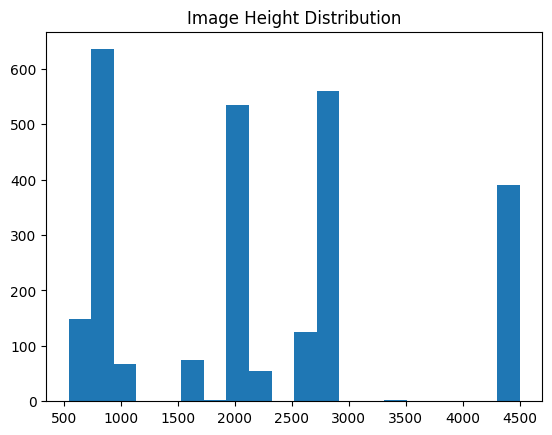

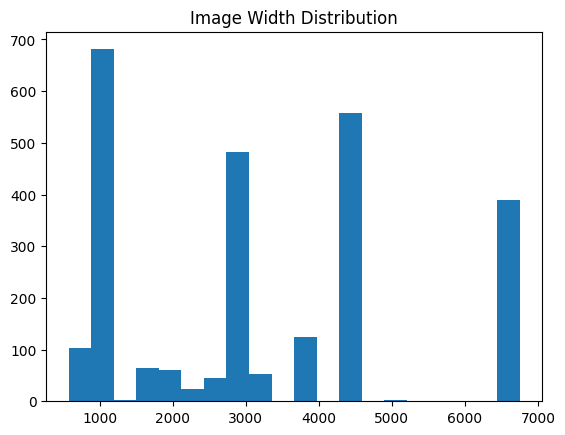

In [4]:
# image resolution distribution

heights = []
widths = []

for img_name in tqdm(train_images):
    img = cv2.imread(str(TRAIN_IMG_DIR / img_name))
    if img is not None:
        h, w, _ = img.shape
        heights.append(h)
        widths.append(w)

plt.hist(heights, bins=20)
plt.title("Image Height Distribution")
plt.show()

plt.hist(widths, bins=20)
plt.title("Image Width Distribution")
plt.show()

In [5]:
# unique check
print("Unique heights:", len(set(heights)))
print("Unique widths:", len(set(widths)))

Unique heights: 101
Unique widths: 104


In [6]:
# Mask Resolution Distribution

mask_heights = []
mask_widths = []

for mask_name in tqdm(masks):
    mask = cv2.imread(str(MASK_DIR / mask_name), 0)
    if mask is not None:
        h, w = mask.shape
        mask_heights.append(h)
        mask_widths.append(w)

print("Mask size unique:", len(set(mask_heights)))

100%|██████████| 2596/2596 [00:23<00:00, 111.64it/s]

Mask size unique: 101


In [7]:
# Masks-Image resolution consistency check

# Filter to get only image files (skip text files)
image_files = [f for f in train_images if f.endswith('.jpg')]
mask_files = [f for f in masks if f.endswith('.png')]

img_sample = cv2.imread(str(TRAIN_IMG_DIR / image_files[0]))
mask_sample = cv2.imread(str(MASK_DIR / mask_files[0]), 0)

print(img_sample.shape, mask_sample.shape)

(767, 1022, 3) (767, 1022)


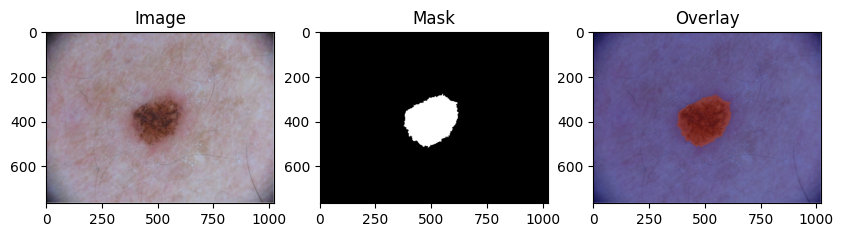

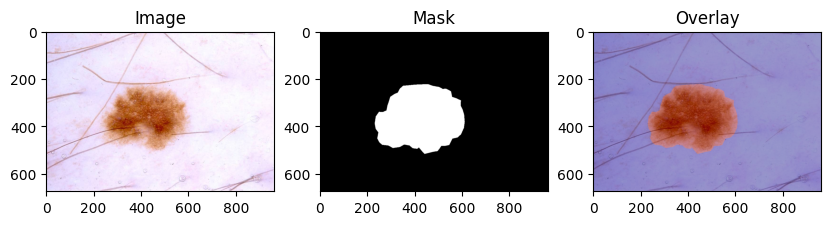

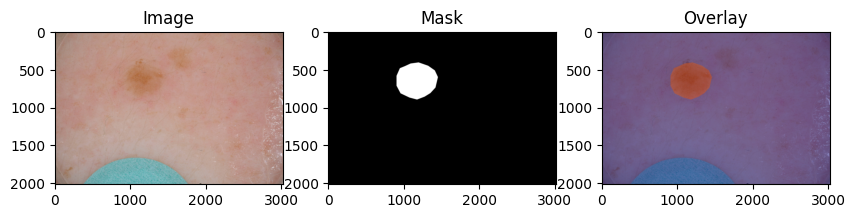

In [8]:
# Check some images
def show_overlay(idx=0):
    img_name = train_images[idx]
    mask_name = img_name.replace(".jpg", "_segmentation.png")

    img = cv2.imread(str(TRAIN_IMG_DIR / img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(str(MASK_DIR / mask_name), 0)

    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Image")

    plt.subplot(1,3,2)
    plt.imshow(mask, cmap="gray")
    plt.title("Mask")

    plt.subplot(1,3,3)
    plt.imshow(img)
    plt.imshow(mask, cmap="jet", alpha=0.4)
    plt.title("Overlay")

    plt.show()


show_overlay(10)
show_overlay(200)
show_overlay(500)

100%|██████████| 2594/2594 [00:30<00:00, 84.95it/s] 


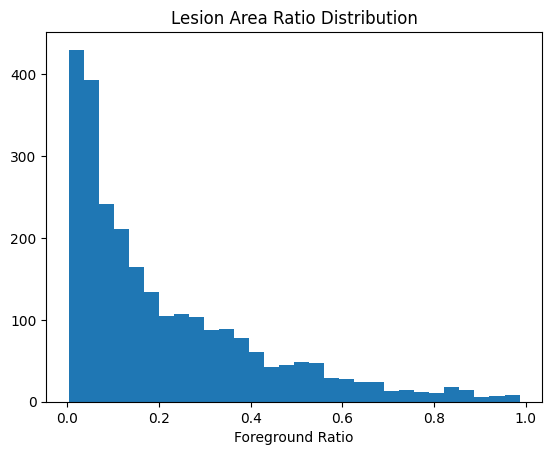

Min ratio: 0.0029767287234042554
Max ratio: 0.9866498311360677
Mean ratio: 0.21402130154382532


In [9]:
# lesion area distribution

areas = []

# Filter to get only mask files (skip text files)
mask_files_only = [f for f in masks if f.endswith('.png')]

for mask_name in tqdm(mask_files_only):
    mask = cv2.imread(str(MASK_DIR / mask_name), 0)
    area = np.sum(mask > 0)
    total = mask.size
    ratio = area / total
    areas.append(ratio)

plt.hist(areas, bins=30)
plt.title("Lesion Area Ratio Distribution")
plt.xlabel("Foreground Ratio")
plt.show()

print("Min ratio:", min(areas))
print("Max ratio:", max(areas))
print("Mean ratio:", np.mean(areas))

In [10]:
# Empty mask detection

empty_masks = []

for mask_name in tqdm(masks):
    mask = cv2.imread(str(MASK_DIR / mask_name), 0)
    if np.sum(mask) == 0:
        empty_masks.append(mask_name)

print("Empty masks:", len(empty_masks))

100%|██████████| 2596/2596 [00:28<00:00, 90.48it/s] 

Empty masks: 0


In [13]:
# Count None Type img

none_count = 0
for img_name in tqdm(train_images):
    img = cv2.imread(str(TRAIN_IMG_DIR / img_name))
    if img is None:
        none_count += 1
print("None type images:", none_count)

100%|██████████| 2596/2596 [02:04<00:00, 20.78it/s] 

None type images: 2
